# 구매요청 중단 EDA

`PURCHASE_REQUEST_ITEMS.csv`에서 `중단` 타깃을 기준으로 기초 탐색을 수행합니다.

- 데이터 크기/컬럼 타입
- 결측 분포
- 타깃(`중단`) 비율
- 범주형/수치형 분포
- 날짜 컬럼 파싱, 텍스트 길이 분포

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Windows에서 한글 라벨용 (없으면 기본 폰트로 두어도 됨)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path("..").resolve()
CSV_PATH = ROOT / "data" / "processed" / "PURCHASE_REQUEST_ITEMS.csv"
print(CSV_PATH, CSV_PATH.exists())

C:\Workspaces\sllm_texttosql_ml_rag_ortools_simulation_langgraph\data\processed\PURCHASE_REQUEST_ITEMS.csv True


## 1. 로드

In [2]:
# 인코딩 이슈 시: encoding="cp949" 또는 encoding_errors="replace" 시도
df = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False)
df.shape

(26472, 51)

In [3]:
df.head(3)

,선택,확정,중단,중단일,중단사유,중단처리자,요청일,요청부서,구매요청번호,요청담당자,...,원천조회,진행조회,등록일시,조달일수,구매발주(수입Order)번호,화학물질오류여부,가용재고보유여부,중단요청,직배송,직배송주소
0,NaN,True,False,NaN,NaN,NaN,2020-04-01,남부영업팀(2020),202004010001,김준수,...,NaN,NaN,NaN,0,YLTK-200401B,NaN,False,False,False,NaN
1,NaN,True,False,NaN,NaN,NaN,2020-04-01,영업1부(2020),202004010002,송주미,...,NaN,NaN,NaN,0,*YIJ-200401A,NaN,False,False,False,NaN
2,NaN,True,False,NaN,NaN,NaN,2020-04-01,동부영업팀(2020),202004010003,김광원,...,NaN,NaN,NaN,0,YF-200401U1,NaN,False,False,False,NaN


In [4]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 26472 entries, 0 to 26471
Data columns (total 51 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   선택               0 non-null      float64
 1   확정               26472 non-null  bool   
 2   중단               26472 non-null  bool   
 3   중단일              0 non-null      float64
 4   중단사유             830 non-null    str    
 5   중단처리자            831 non-null    str    
 6   요청일              26472 non-null  str    
 7   요청부서             26472 non-null  str    
 8   구매요청번호           26472 non-null  int64  
 9   요청담당자            26472 non-null  str    
 10  품번               26471 non-null  str    
 11  품명               26472 non-null  str    
 12  품목약명             26472 non-null  str    
 13  품목영문명            26411 non-null  str    
 14  구매요청수량           26472 non-null  int64  
 15  품목영문약명           11479 non-null  str    
 16  규격               19689 non-null  str    
 17  품목분류1            26472 

## 2. 결측

In [5]:
na = df.isna().mean().sort_values(ascending=False)
na[na > 0].head(25)

선택          1.000000
중단일         1.000000
등록일시        1.000000
직배송주소       1.000000
구매요청구분      1.000000
자재소요번호      1.000000
생산계획번호      1.000000
원천조회        1.000000
진행조회        1.000000
화학물질오류여부    1.000000
품목담당자       1.000000
발주예정일       0.999962
중단사유        0.968646
중단처리자       0.968608
PONO        0.887542
비고          0.775612
품목영문약명      0.566372
비고2         0.563426
품목분류4       0.327251
품목분류2       0.281505
규격          0.256233
Maker       0.191448
품목분류3       0.171426
수주번호        0.114725
수주거래처       0.114725
dtype: float64

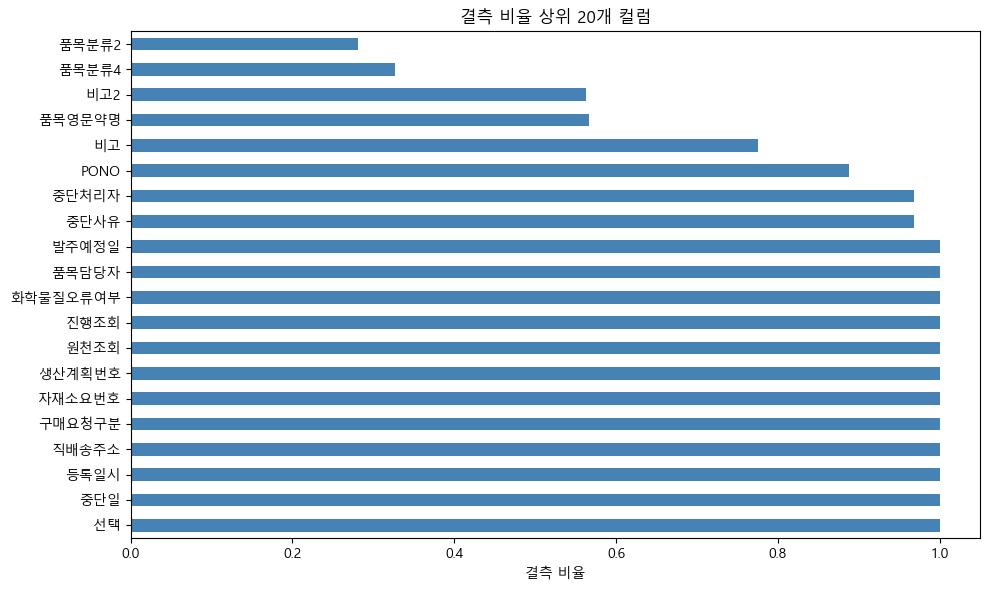

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
top_na = na[na > 0].head(20)
top_na.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("결측 비율")
ax.set_title("결측 비율 상위 20개 컬럼")
plt.tight_layout()
plt.show()

## 3. 타깃 정의: `중단`

- **이진 타깃 예시**: `중단`이 True/"Y"/1 이면 양성(중단됨), 그 외 음성.
- 실제 값 분포를 보고 bool/object 중 무엇으로 들어왔는지 확인합니다.

In [7]:
if "중단" not in df.columns:
    raise KeyError("컬럼 '중단'이 없습니다. CSV 헤더를 확인하세요.")

df["중단"].dtype, df["중단"].value_counts(dropna=False)

(dtype('bool'),
 중단
 False    25641
 True       831
 Name: count, dtype: int64)

In [8]:
def to_binary_stop(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (bool, np.bool_)):
        return int(bool(s))
    t = str(s).strip().lower()
    if t in ("true", "1", "y", "yes", "중단"):
        return 1
    if t in ("false", "0", "n", "no", ""):
        return 0
    return np.nan


y = df["중단"].map(to_binary_stop)
print("중단 타깃 분포\n", y.value_counts(dropna=False))
pos_rate = y.dropna().mean()
print(f"중단=1 비율: {pos_rate:.4f}")

중단 타깃 분포
 중단
0    25641
1      831
Name: count, dtype: int64
중단=1 비율: 0.0314


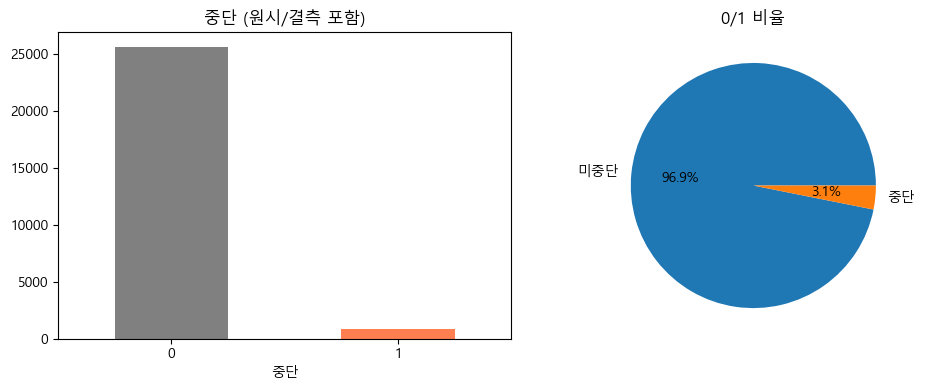

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y.value_counts(dropna=False).plot(kind="bar", ax=ax[0], color=["gray", "coral", "steelblue"])
ax[0].set_title("중단 (원시/결측 포함)")
ax[0].tick_params(axis="x", rotation=0)
y2 = y.dropna().astype(int)
order = sorted(y2.unique())
labels = ["미중단", "중단"] if order == [0, 1] else [str(x) for x in order]
y2.value_counts(normalize=True).reindex(order).plot(kind="pie", ax=ax[1], autopct="%1.1f%%", labels=labels)
ax[1].set_ylabel("")
ax[1].set_title("0/1 비율")
plt.tight_layout()
plt.show()

## 4. 수치형

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
len(num_cols), num_cols[:15]

(18,
 ['선택',
  '중단일',
  '구매요청번호',
  '구매요청수량',
  '품의진행수량',
  '발주진행수량',
  '수주번호',
  'PONO',
  '품목담당자',
  '구매요청구분',
  '생산계획번호',
  '자재소요번호',
  '원천조회',
  '진행조회',
  '등록일시'])

In [11]:
if num_cols:
    display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
선택,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
중단일,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
구매요청번호,26472.0,2.020052e+11,8.324005e+05,2.020040e+11,2.020042e+11,2.020052e+11,2.020061e+11,2.020063e+11
구매요청수량,26472.0,3.806475e+00,1.923850e+01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+03
품의진행수량,26472.0,3.720573e+00,1.923090e+01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+03
발주진행수량,26472.0,3.720573e+00,1.923090e+01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+03
수주번호,23435.0,2.020052e+12,1.230622e+07,2.019063e+12,2.020042e+12,2.020052e+12,2.020061e+12,2.020071e+12
PONO,2977.0,1.148270e+06,7.747296e+02,1.146751e+06,1.147614e+06,1.148294e+06,1.148937e+06,1.149600e+06
품목담당자,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
구매요청구분,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. 범주형 컬럼 분포

문자열 컬럼별 고유값 개수를 확인합니다.

In [12]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
card = (
    pd.DataFrame({"nunique": [df[c].nunique(dropna=False) for c in cat_cols], "dtype": [df[c].dtype for c in cat_cols]}, index=cat_cols)
    .sort_values("nunique", ascending=False)
)
card.head(25)

,nunique,dtype
품번,14030,str
품명,13561,str
품목약명,13512,str
품목영문명,13455,str
품목영문약명,5135,str
구매발주(수입Order)번호,3653,str
비고2,3129,str
규격,1698,str
수주거래처,1623,str
비고,1559,str


## 6. 주요 범주형과 타깃 비율

주요 컬럼별로 `중단=1` 비율을 비교합니다.

In [13]:
def crosstab_rate(col, top_n=12):
    if col not in df.columns:
        print(f"(없음) {col}")
        return
    tmp = df[[col]].copy()
    tmp["y"] = y
    tmp = tmp.dropna(subset=["y"])
    vc = tmp[col].astype(str).value_counts().head(top_n).index
    sub = tmp[tmp[col].astype(str).isin(vc)]
    ct = pd.crosstab(sub[col], sub["y"], normalize="index")
    display(ct)


for c in ["요청부서", "창고", "진행상태", "내/외자", "Maker"]:
    crosstab_rate(c)

y,0,1
요청부서,,
남부영업팀(2020),0.940120,0.059880
동부영업팀(2020),0.981512,0.018488
마케팅1부,0.999403,0.000597
영업10팀(2020),0.962485,0.037515
영업1팀(2020),0.959924,0.040076
영업2팀(2020),0.946831,0.053169
영업3팀(2020),0.958128,0.041872
영업4팀(2020),0.955556,0.044444
영업5팀(2020),0.990099,0.009901


y,0,1
창고,,
군포창고,1.000000,0.000000
기본창고(평택물류),0.968599,0.031401
지하창고(안양물류),1.000000,0.000000


y,0,1
진행상태,,
완료,1.0,0.0
중단,0.0,1.0
확정(승인),1.0,0.0


y,0,1
내/외자,,
내수,0.965213,0.034787
직수입,0.980931,0.019069


y,0,1
Maker,,
Agilent,0.988207,0.011793
Chemservice,0.923567,0.076433
Chromsystems,1.000000,0.000000
Hamilton(SYR),1.000000,0.000000
Life Technologies,0.907417,0.092583
Merck Millipore,0.944553,0.055447
Merck-LEBM,0.997253,0.002747
SCP SCIENCE,1.000000,0.000000
SUPELCO,0.988743,0.011257


## 7. 날짜 후보 컬럼

`pd.to_datetime(..., errors="coerce")`로 파싱 성공 비율과 min/max만 확인한다.

In [14]:
date_candidates = [c for c in ["요청일", "요청납기일", "발주예정일", "등록일시", "중단일"] if c in df.columns]
for c in date_candidates:
    s = pd.to_datetime(df[c], errors="coerce")
    print(c, "파싱 성공 비율:", s.notna().mean().round(4), "샘플 min/max:", s.min(), s.max())

요청일 파싱 성공 비율: 1.0 샘플 min/max: 2020-04-01 00:00:00 2020-06-30 00:00:00
요청납기일 파싱 성공 비율: 1.0 샘플 min/max: 2020-04-08 00:00:00 2021-01-01 00:00:00
발주예정일 파싱 성공 비율: 0.0 샘플 min/max: 2020-04-16 00:00:00 2020-04-16 00:00:00
등록일시 파싱 성공 비율: 0.0 샘플 min/max: NaT NaT
중단일 파싱 성공 비율: 0.0 샘플 min/max: NaT NaT


## 8. 텍스트 컬럼 길이 분포

`비고`, `비고2`, `중단사유`는 원문 대신 길이 분포만 확인합니다.

비고 — len describe:


count    5940.000000
mean       41.283165
std        26.644838
min         1.000000
25%        20.000000
50%        36.000000
75%        55.000000
max       100.000000
Name: 비고, dtype: float64

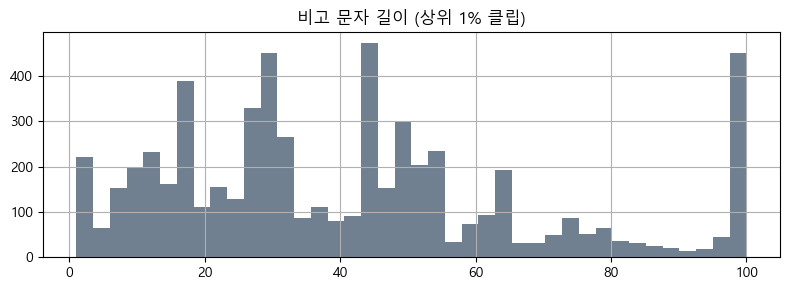

비고2 — len describe:


count    11557.000000
mean         9.288570
std          6.788838
min          1.000000
25%          6.000000
50%          7.000000
75%         12.000000
max        100.000000
Name: 비고2, dtype: float64

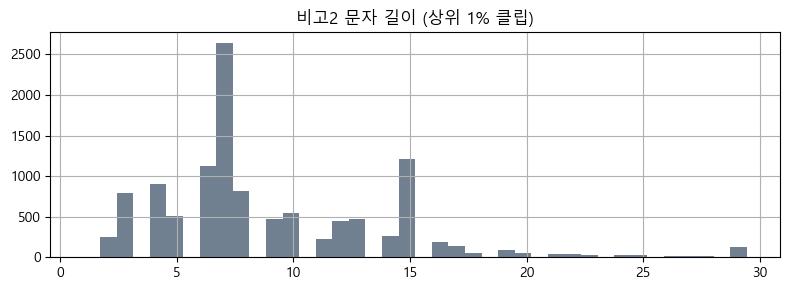

중단사유 — len describe:


count    830.000000
mean       6.657831
std        6.264267
min        1.000000
25%        2.000000
50%        4.000000
75%        9.000000
max       37.000000
Name: 중단사유, dtype: float64

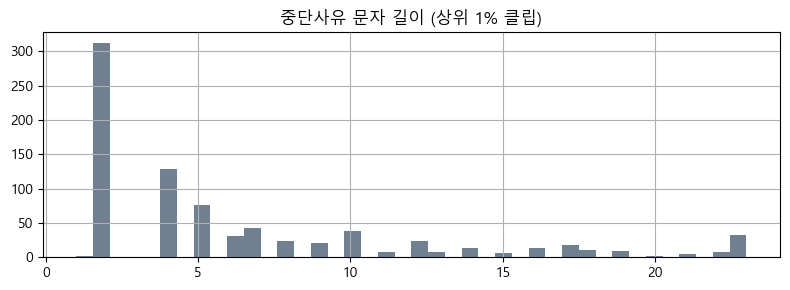

In [15]:
text_cols = [c for c in ["비고", "비고2", "중단사유"] if c in df.columns]
for c in text_cols:
    lens = df[c].astype(str).str.len()
    print(c, "— len describe:")
    display(lens.describe())
    fig, ax = plt.subplots(figsize=(8, 3))
    lens.clip(upper=lens.quantile(0.99)).hist(bins=40, ax=ax, color="slategray")
    ax.set_title(f"{c} 문자 길이 (상위 1% 클립)")
    plt.tight_layout()
    plt.show()

## 9. 중단 건의 사유 입력 비율

`중단=1`인 행에서 `중단사유`가 입력된 비율을 확인합니다.

In [16]:
if "중단사유" in df.columns:
    mask = y == 1
    filled = df.loc[mask, "중단사유"].notna() & (df.loc[mask, "중단사유"].astype(str).str.strip() != "")
    print("중단=1 행 수:", int(mask.sum()))
    print("그 중 중단사유 비어있지 않은 비율:", filled.mean())

중단=1 행 수: 831
그 중 중단사유 비어있지 않은 비율: 0.9987966305655837


## 10. EDA 요약

- `중단` 컬럼은 0/1 타깃으로 변환해 분석했습니다.
- 결측이 큰 컬럼과 고유값이 큰 범주형 컬럼을 확인했습니다.
- 주요 범주형 컬럼별 `중단` 비율 차이를 확인했습니다.
- 날짜 컬럼은 파싱 성공률을 점검했습니다.
- 텍스트 컬럼은 내용 노출 없이 길이 분포만 확인했습니다.